# Mall Customer Segmentation

## Introduction

**Dataset:** https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

A supermarket wants to better understand their customers by grouping them based on their demographics and spending habits. The goal is to identify key customer segments, especially those most likely to respond to marketing (Target Customers), so that the marketing team can plan more effective strategies.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Import Dataset

In [2]:
df = pd.read_csv("../data/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## Checking for Duplicates and Missing Values

In [3]:
df.duplicated().any()

np.False_

In [4]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## Removing Outliers

We remove outliers because they are extreme values that do not represent the general pattern of the data and can distort your results. In clustering, outliers can pull cluster centers away from the true groups, create fake clusters, or make similar data points look more different than they really are. Removing them helps the model to focus on the real structure in the data, leading to more stable and meaningful clusters.

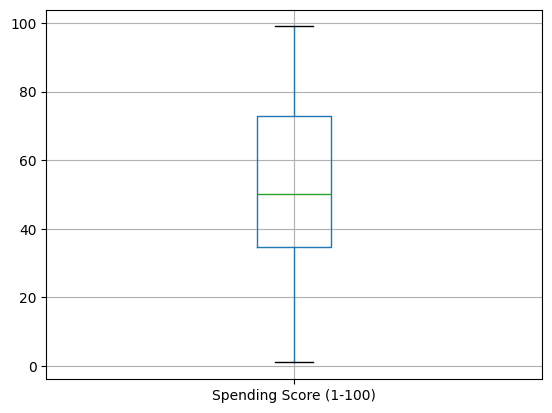

In [6]:
df.boxplot(column="Spending Score (1-100)")
plt.show()

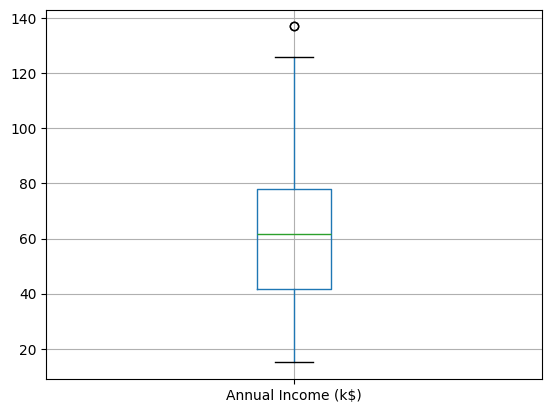

In [7]:
df.boxplot(column="Annual Income (k$)")
plt.show()

In [8]:
df = df[df["Annual Income (k$)"] < 130]

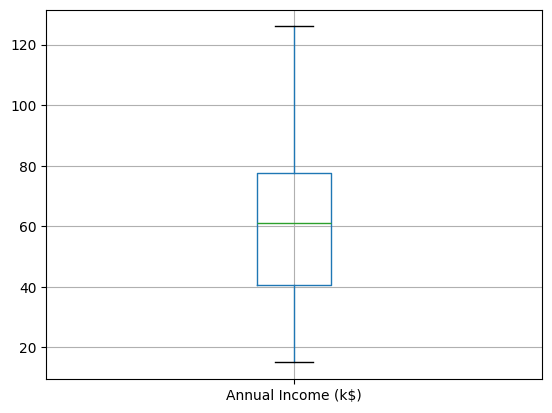

In [9]:
df.boxplot(column="Annual Income (k$)")
plt.show()

## Getting the Features

In this demonstration, we will use only `Annual Income (k$)` and `Spending Score (1-100)` as our features.

In [10]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

Let us take a sneak peek at our data with a scatter plot.

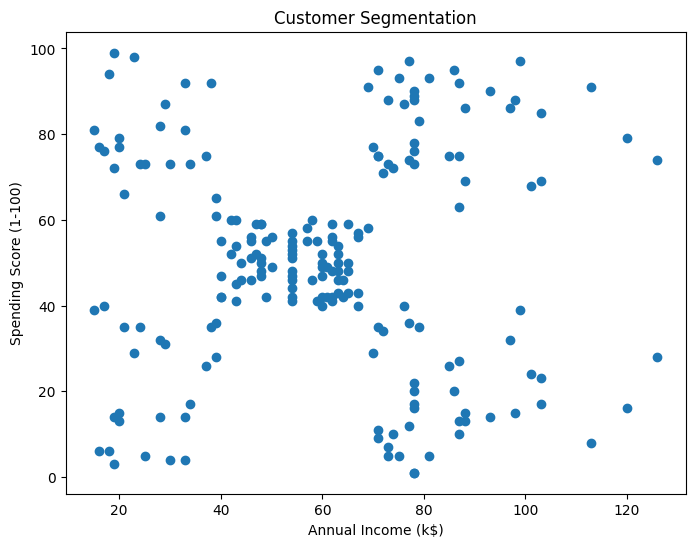

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(x=X["Annual Income (k$)"], y=X["Spending Score (1-100)"])
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")
plt.show()

## Scaling the Data

K-Means clustering is sensitive to the scale of the features because it relies on distance calculations. If one feature has much bigger values than others, it will unfairly influence the distance and skew the clusters. Scaling puts all features on the same range so each one contributes equally.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Elbow Method

In cluster analysis, the elbow method is a heuristic used in determining the number of clusters in a data set. The method consists of plotting the explained variation as a function of the number of clusters and picking the elbow of the curve as the number of clusters to use.

The Elbow Method helps us find the optimal k value (number of clusters) in K-Means Clustering by:

- iterating over a range of k values
- For each k, calculate the **Within-Cluster Sum of Squares (WCSS)**. WCSS is also known as **Inertia**.

In [13]:
from sklearn.cluster import KMeans

inertias = []

for k in range(1, 11):
    k_means = KMeans(n_clusters=k)
    k_means.fit(X_scaled)
    inertias.append(k_means.inertia_)

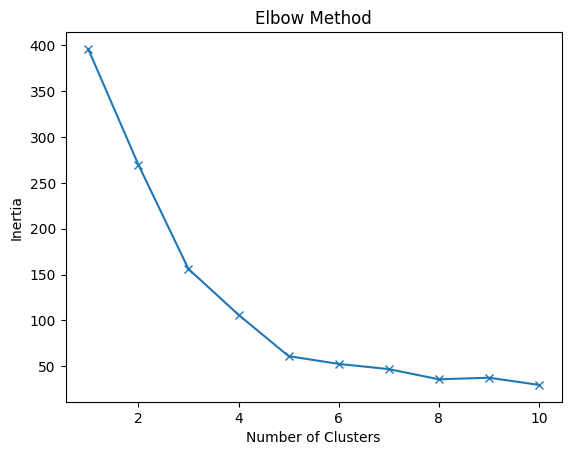

In [14]:
plt.plot(range(1, 11), inertias, marker="x")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

We look at the curve and find the “elbow” point, where the decrease in WCSS starts to slow down significantly. 

For our plot, `5` is the elbow point.

## Training the Model

In [15]:
k_means = KMeans(n_clusters=5)
k_means.fit(X_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](5, 2)",

## Visualization

Now we can visualize the data with the clusters.

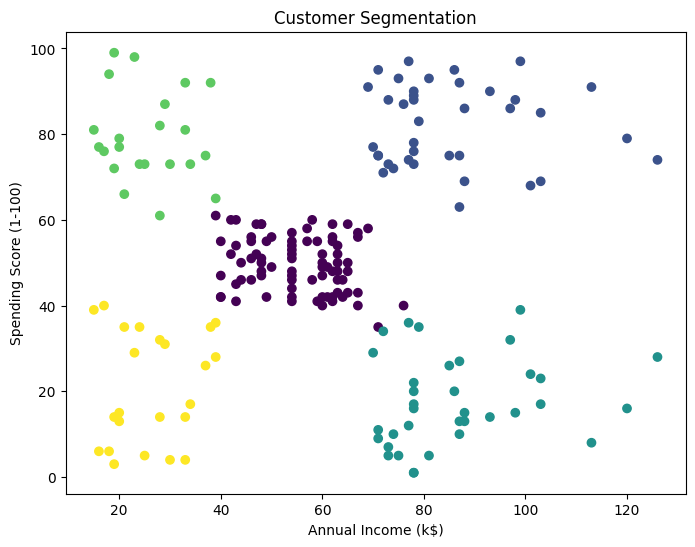

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(x=X["Annual Income (k$)"], y=X["Spending Score (1-100)"], c=k_means.labels_)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation")
plt.show()

## Evaluation

### Silhouette Score

The **Silhouette Score** is a metric that measures how well data points are clustered. It evaluates how similar a point is to its **own cluster** (cohesion) compared to **other clusters** (separation).

For each data point $i$, the silhouette score $s(i)$ is calculated as:

$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

where:
- **$a(i)$ (Intra-cluster distance):** The average distance between $i$ and all other points in the same cluster.
- **$b(i)$ (Inter-cluster distance):** The average distance between $i$ and points in the nearest different cluster.

---
- $s(i) \approx 1$ → **Well-clustered** (points are close to their own cluster and far from others).
- $s(i) \approx 0$ → **Overlapping clusters** (points are on the boundary between two clusters).
- $s(i) < 0$ → **Misclassified points** (closer to another cluster than their own).

In [17]:
from sklearn.metrics import silhouette_score

silhouette_score(X, k_means.labels_)

0.5606825090788626

## Assignment

**Dataset:** https://www.kaggle.com/datasets/neurocipher/kmeans-clustering-2d-dataset

The above is a simple synthetic 2D dataset designed specifically for practicing clustering. Your task is to visualize the data, determine a suitable number of clusters, fit the K-Means model, and then visualize the resulting clusters to see how well the algorithm separates the data points.